# Modelos estocásticos y redes neuronales

**Materia:** Análisis de Series de Tiempo y Pronósticos (1C-2026)

**Grupo:** 9

**Integrantes:**

- Lucas Achaval - Email: lachavalrodriguez@estudiantes.unsam.edu.ar
- Marcos Achaval - Email: machavalrodriguez@unsam-bue.edu.ar

**Título del entregable:** Modelos estocásticos y redes neuronales

**Conjunto de datos original:** dataset propio de una estación meteorológica en un club náutico de Potrerillos (disponibles en [Windguru](https://www.windguru.cz/station/15338)).

## Resumen

Este trabajo busca construir un modelo de pronóstico horario de viento promedio (`wind_avg`) en Potrerillos, Mendoza, con horizonte de 12 horas, evaluado mediante MAE, RMSE y R². En la primera entrega caracterizamos la serie (ciclo diurno marcado, estacionariedad confirmada por ADF, picos de ACF/PACF en lags 1-2 y 20-24) y entrenamos un LassoCV con 24 lags, 6 exógenas y codificación cíclica de la hora, que redujo el RMSE de 3.589 a 2.704 kt (mejora del 24.7%) y elevó el R² de 0.117 a 0.498 frente a una persistencia estacional, sin signos de sobreajuste. Esta entrega avanza con benchmark, modelos estocásticos y redes neuronales.

## Carga y preprocesamiento

Replicamos el preprocesamiento del primer entregable: lectura del archivo crudo, remuestreo horario (mediana para variables lineales, media circular para `wind_direction`) y agregado del atributo auxiliar `interval`. La variable `wind_min` queda fuera porque está completamente vacía, y `gustiness` se omite porque es una derivada de `wind_avg` y `wind_max`.

In [11]:
import numpy as np
import pandas as pd
from scipy import stats


def circular_mean(angles):
    a = angles.dropna()
    return round(stats.circmean(a, high=360, low=0)) if a.size > 0 else np.nan


df = pd.read_csv("../data/station_15338.csv")
df.set_index(pd.to_datetime(df["datetime"]), inplace=True)
df.drop(columns=["datetime", "unixtime"], inplace=True)

median_cols = ["wind_avg", "wind_max", "temperature", "rh", "mslp"]
df = (
    df.resample("1h")
    .agg({**{c: "median" for c in median_cols}, "wind_direction": circular_mean})
    .asfreq("1h")
)
df["interval"] = np.float32((df.index - df.index[0]).total_seconds() / 60)
df.head(3)

,wind_avg,wind_max,temperature,rh,mslp,wind_direction,interval
datetime,,,,,,,
2025-08-01 00:00:00,7.40,11.3,9.9,73.8,855.30,77.0,0.0
2025-08-01 01:00:00,2.30,3.5,8.8,77.0,855.20,192.0,60.0
2025-08-01 02:00:00,1.75,3.2,7.9,81.0,854.55,162.0,120.0


## Modelo de referencia (benchmark)

Como benchmark adoptamos la **persistencia estacional** con período 24 h. Para un instante $t$ y un horizonte $h \leq 24$:

$$\hat{y}_{t+h} = y_{t+h-24}$$

Es decir, el viento de cada hora se pronostica con el valor observado a la misma hora del día anterior. Justificación de la elección:

- **Simple y de interpretación inmediata.** No tiene parámetros a estimar.
- **Aprovecha la única estructura fuerte de la serie.** El ACF del primer entregable mostró un pico claro en el lag 24 (autocorrelación $\approx 0.5$). Una persistencia simple ($\hat{y}_{t+h}=y_t$) ignoraría esa estacionalidad y rendiría peor.
- **Línea de base no trivial.** Cualquier modelo más complejo deberá superar este desempeño para justificar su costo.

Implementamos la persistencia estacional como un estimador de `scikit-learn` y la evaluamos con `TimeSeriesSplit` de 3 carpetas y `gap = HORIZONTE`, igual que para los modelos posteriores.

In [12]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)


class SeasonalNaiveEstimator(RegressorMixin, BaseEstimator):
    """Pronostica y(t+h) repitiendo y(t+h - period). No tiene parámetros a ajustar."""

    def __init__(self, period=24):
        self.period = period

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def predict(self, X):
        return X.iloc[:, 0].to_numpy()

In [13]:
from sklearn.model_selection import TimeSeriesSplit

HORIZONTE = 12
PERIODO = 24
N_SPLITS = 3

tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=HORIZONTE)
modelo = SeasonalNaiveEstimator(period=PERIODO)

filas = []
for h in range(1, HORIZONTE + 1):
    objetivo = df["wind_avg"].shift(-h).rename("objetivo")
    persistencia = df["wind_avg"].shift(PERIODO - h).rename("persistencia")
    datos = pd.concat([persistencia, objetivo], axis=1).dropna()

    X = datos[["persistencia"]]
    y = datos["objetivo"]

    for fold, (idx_train, idx_test) in enumerate(tscv.split(X), start=1):
        modelo.fit(X.iloc[idx_train], y.iloc[idx_train])
        y_pred = modelo.predict(X.iloc[idx_test])
        y_test = y.iloc[idx_test]
        filas.append(
            {
                "horizonte": h,
                "fold": fold,
                "mae": mean_absolute_error(y_test, y_pred),
                "rmse": root_mean_squared_error(y_test, y_pred),
                "r2": r2_score(y_test, y_pred),
            }
        )

bench = pd.DataFrame(filas)
bench_h = (
    bench.groupby("horizonte")[["mae", "rmse", "r2"]]
    .mean()
    .round(3)
    .rename(columns={"mae": "MAE", "rmse": "RMSE", "r2": "R²"})
)
bench_h

,MAE,RMSE,R²
horizonte,,,
1,2.558,3.607,0.103
2,2.558,3.607,0.103
3,2.558,3.607,0.103
4,2.558,3.607,0.103
5,2.558,3.607,0.103
6,2.558,3.607,0.103
7,2.558,3.607,0.103
8,2.558,3.607,0.103
9,2.558,3.607,0.103


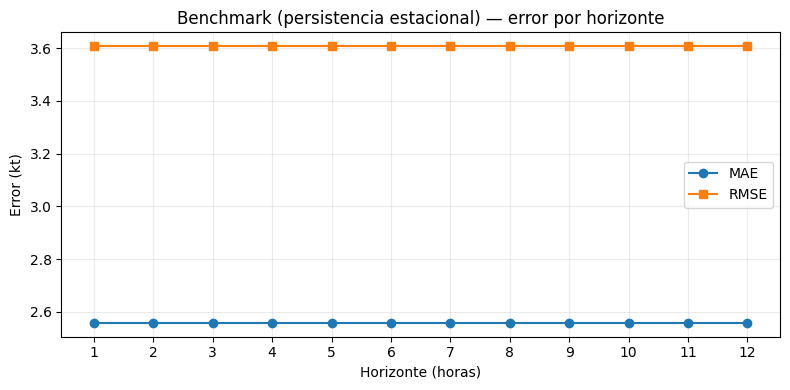

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bench_h.index, bench_h["MAE"], marker="o", label="MAE")
ax.plot(bench_h.index, bench_h["RMSE"], marker="s", label="RMSE")
ax.set_title("Benchmark (persistencia estacional) — error por horizonte")
ax.set_xlabel("Horizonte (horas)")
ax.set_ylabel("Error (kt)")
ax.set_xticks(range(1, HORIZONTE + 1))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

### Desempeño del benchmark

La tabla y el gráfico anteriores muestran MAE, RMSE y R² del benchmark para cada horizonte de 1 a 12 horas. Observaciones:

- **Error casi constante con el horizonte.** Como la predicción siempre se construye con un dato de 24 h atrás, no importa cuán lejos esté el target dentro de las próximas 24 horas. El error se mantiene en el mismo orden. Este perfil plano será un contraste útil frente a modelos con memoria de corto plazo (ARIMA, redes neuronales), que tienden a degradarse a medida que se aleja el horizonte.
- **R² positivo pero bajo (~0.1).** La estacionalidad diaria sola explica una fracción modesta de la varianza del viento, dejando margen amplio para que los modelos posteriores aporten información adicional vía lags cercanos y variables exógenas.

A partir de aquí, este será el desempeño mínimo que deben superar los modelos estocásticos y de redes neuronales para resultar útiles.

## Modelo estocástico

A partir de las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) buscamos un modelo estocástico que ajuste bien la dinámica de `wind_avg`. El primer entregable ya mostró tres hechos relevantes para esta etapa:

- La prueba ADF sobre la serie original arrojó un estadístico de $-11.4$ y un $p$-valor de $7.6 \times 10^{-21}$, rechazando con holgura la hipótesis de raíz unitaria. **La serie es estacionaria**.
- El ACF mostró un pico claro en el lag 24 y el PACF resaltó los lags 1-2 y 20-24.
- El espectro de potencias estuvo dominado por la frecuencia de 1 ciclo/día, con un segundo pico (más débil) en 2 ciclos/día.

### ¿Por qué SARIMA y no AR, MA, ARMA o ARIMA?

La materia presenta la familia de modelos en escalera: AR, MA, ARMA (estacionarios), ARIMA (no estacionarios por tendencia, vía diferenciación regular) y SARIMA (cuando además hay estructura estacional). La elección entre ellos no es discrecional, se desprende de qué muestre la serie. Las guías 4 y 5 establecen las reglas:

| Modelo | ACF esperado | PACF esperado |
|---|---|---|
| AR($p$) | decae | corta en lag $p$ |
| MA($q$) | corta en lag $q$ | decae |
| ARMA($p,q$) | decae | decae |

- **AR puro queda descartado.** La PACF de `wind_avg` no corta limpio: tiene un primer cluster de 2 lags significativos (1-2) y otro cluster alrededor de los lags 20-24. Para que un AR(p) capture el pico de lag 24 con la PACF cortando ahí, haría falta $p = 24$ (24 coeficientes), violando el criterio de parsimonia.
- **MA puro queda descartado.** El ACF no corta en ningún lag corto: decae con oscilaciones (efecto día/noche en lag 12, pico positivo en lag 24). Un MA(q) requiere que la ACF se anule a partir de cierto $q$, condición que aquí no se cumple.
- **ARMA estacional-agnóstico queda descartado.** ARMA puede modelar un ACF/PACF que decaen, pero no incorpora la noción de **período**. El pico aislado en lag 24 de la ACF es estacional, no una correlación corta extendida, y un ARMA tendría que aproximarla con muchos coeficientes consecutivos. El espectro de potencias confirma que el ciclo diario es la fuente dominante de varianza, no ruido autocorrelacionado de corto alcance.
- **ARIMA queda descartado porque no hace falta diferenciación regular.** El ADF confirma estacionariedad, así que $d = 0$ y ARIMA(p,0,q) colapsa al ARMA ya descartado.
- **SARIMA es el ajuste natural.** Modela explícitamente la estacionalidad con un solo término $P$ o $Q$ aplicado al rezago $\mathbf{B}^{24}$, según la guía 5:

$$\Theta_P(\mathbf{B}^{24})\,\Theta_p(\mathbf{B})\,(1-\mathbf{B}^{24})^{D}\,(1-\mathbf{B})^{d}\,x_t = \Phi_Q(\mathbf{B}^{24})\,\Phi_q(\mathbf{B})\,w_t$$

Así un único coeficiente estacional reemplaza decenas de coeficientes no estacionales. Tomamos $d = 0$ (ADF) y, en principio, $D = 0$ porque el ADF también pasa sobre la serie no diferenciada y el pico estacional ya está presente sin necesidad de remover una tendencia estacional. Si los residuos del modelo final muestran estructura sobreviviente cerca de múltiplos de 24, reconsideramos $D = 1$.

El modelo a explorar es entonces un **SARIMA(p,0,q)(P,0,Q,24)**, dejando para la búsqueda con AIC la elección concreta de $p, q, P, Q$.

### Preparación de la serie

Para que la búsqueda de parámetros y el posterior análisis de residuos sean consistentes con la evaluación que haremos en la próxima sección, separamos un 80% inicial como entrenamiento y reservamos el 20% final para test. Los 276 valores faltantes (4.5% de la serie) los completamos con `ffill().bfill()`, igual que en la descomposición estacional del entregable 1.

In [15]:
serie = df["wind_avg"].ffill().bfill()

n_train = int(0.8 * len(serie))
serie_train = serie.iloc[:n_train]
serie_test = serie.iloc[n_train:]

print(f"Train: {serie_train.index[0]} → {serie_train.index[-1]}  ({len(serie_train)} obs)")
print(f"Test:  {serie_test.index[0]} → {serie_test.index[-1]}  ({len(serie_test)} obs)")

Train: 2025-08-01 00:00:00 → 2026-02-21 19:00:00  (4916 obs)
Test:  2026-02-21 20:00:00 → 2026-04-14 00:00:00  (1229 obs)


### Funciones de autocorrelación sobre el training

Repetimos el análisis del entregable 1 pero **solo sobre el subconjunto de training**, para evitar mirar el test al elegir los hiperparámetros. Esto es importante metodológicamente: cualquier inspección que hagamos para definir el modelo (orden, estacionalidad) debe basarse exclusivamente en datos vistos.

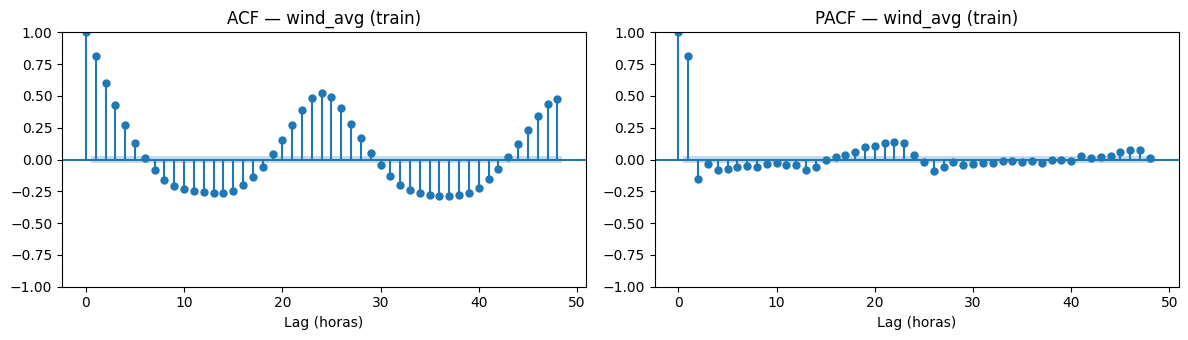

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(serie_train, lags=48, bartlett_confint=False, ax=axes[0])
axes[0].set_title("ACF — wind_avg (train)")
axes[0].set_xlabel("Lag (horas)")

plot_pacf(serie_train, lags=48, ax=axes[1])
axes[1].set_title("PACF — wind_avg (train)")
axes[1].set_xlabel("Lag (horas)")

plt.tight_layout()

El comportamiento sobre el training reproduce lo observado en el entregable 1: PACF significativa en lags 1-2 y entre 20-24, ACF con decaimiento lento y pico positivo en lag 24. Esto confirma la elección de SARIMA argumentada arriba y permite definir la grilla a explorar:

- $p \in \{0, 1, 2\}$ (PACF significativa hasta lag 2)
- $q \in \{0, 1\}$ (MA corto opcional)
- $P, Q \in \{0, 1\}$ (un solo término estacional alcanza para capturar el pico de lag 24)
- $d = D = 0$, $s = 24$, `trend = 'c'`

Son $3 \times 2 \times 2 \times 2 = 24$ combinaciones, en línea con el criterio de **parsimonia**.

### Selección del orden con el criterio de Akaike (AIC)

Iteramos sobre la grilla y, para cada combinación, ajustamos un SARIMA con `statsmodels.tsa.arima.model.ARIMA` y registramos el AIC. El AIC se define como

$$\mathrm{AIC} = -2 \log \mathcal{L} + 2 k$$

donde $\mathcal{L}$ es la verosimilitud del modelo y $k$ es el número de parámetros. Penaliza la cantidad de parámetros, por lo que minimizarlo selecciona el modelo más simple compatible con los datos (criterio de parsimonia). Envolvemos el ajuste en `try/except` para descartar combinaciones que no converjan, igual que en la guía 5.

In [17]:
from itertools import product
from tqdm import tqdm
from statsmodels.tsa.arima.model import ARIMA

ps, qs, Ps, Qs = [0, 1, 2], [0, 1], [0, 1], [0, 1]
S = 24

aic_final_df = pd.DataFrame({"p": [], "q": [], "P": [], "Q": [], "AIC": []})

for p, q, P, Q in tqdm(list(product(ps, qs, Ps, Qs))):
    try:
        model = ARIMA(
            serie_train,
            order=(p, 0, q),
            seasonal_order=(P, 0, Q, S),
            trend="c",
        )
    except:
        continue
    res = model.fit()
    aic_df = pd.DataFrame({"p": [p], "q": [q], "P": [P], "Q": [Q], "AIC": [res.aic]})
    aic_final_df = pd.concat([aic_final_df, aic_df])

aic_final_df.sort_values(by="AIC").reset_index(drop=True).head(10)

100%|██████████| 24/24 [02:31<00:00,  6.30s/it]


,p,q,P,Q,AIC
0,2.0,1.0,1.0,1.0,20496.123448
1,1.0,1.0,1.0,1.0,20501.470215
2,2.0,0.0,1.0,1.0,20503.666777
3,1.0,0.0,1.0,1.0,20514.752748
4,2.0,1.0,1.0,0.0,21167.279026
5,2.0,1.0,0.0,1.0,21198.973119
6,2.0,0.0,1.0,0.0,21220.108075
7,1.0,1.0,1.0,0.0,21220.480090
8,1.0,0.0,1.0,0.0,21267.506863
9,2.0,0.0,0.0,1.0,21268.067111


La tabla anterior ordena las 24 combinaciones por AIC creciente. Tomamos como modelo ganador la primera fila (AIC mínimo).

### Ajuste del modelo ganador

Refitteamos el orden ganador para inspeccionar los coeficientes con `summary()`: nos interesa ver si todos los términos son estadísticamente significativos (columna `P>|z|` cerca de cero) y si las raíces de los polinomios caen fuera del círculo unitario (condición de estacionariedad e invertibilidad).

In [18]:
best_order = aic_final_df.iloc[np.argmin(aic_final_df["AIC"]), :]
p_best, q_best = int(best_order["p"]), int(best_order["q"])
P_best, Q_best = int(best_order["P"]), int(best_order["Q"])

print(f"Mejor orden: SARIMA({p_best},0,{q_best})({P_best},0,{Q_best},{S})  "
      f"— AIC = {best_order['AIC']:.2f}")

modelo_best = ARIMA(
    serie_train,
    order=(p_best, 0, q_best),
    seasonal_order=(P_best, 0, Q_best, S),
    trend="c",
)
res_best = modelo_best.fit()
res_best.summary()

Mejor orden: SARIMA(2,0,1)(1,0,1,24)  — AIC = 20496.12


<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                         wind_avg   No. Observations:                 4916
Model:             ARIMA(2, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -10241.062
Date:                          Tue, 19 May 2026   AIC                          20496.123
Time:                                  15:27:03   BIC                          20541.625
Sample:                              08-01-2025   HQIC                         20512.085
                                   - 02-21-2026                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2394      0.731      7.170      0.000       3.807       6.672
ar.L1          0.2532      0.145      1.745      0.081      -0.031       0.538
ar.L2          0.3016      0.107      2.809      0.005       0.091       0.512
ma.L1          0.5062      0.142      3.567      0.000       0.228       0.784
ar.S.L24       0.9964      0.001    912.401      0.000       0.994       0.999
ma.S.L24      -0.9544      0.005   -210.458      0.000      -0.963      -0.946
sigma2         3.7505      0.045     83.941      0.000       3.663       3.838
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):              7252.76
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               0.93   Skew:                             1.29
Prob(H) (two-sided):                  0.16   Kurtosis:                         8.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Diagnóstico de residuos

Para confirmar que el orden elegido es adecuado revisamos los residuos: si el modelo captura toda la estructura, los residuos deben comportarse como un ruido blanco (independientes, idénticamente distribuidos, media cero). Usamos `plot_diagnostics()` de statsmodels, el panel que la guía 4 introduce y que agrupa:

1. **Residuos estandarizados en el tiempo:** no debería verse tendencia, heterocedasticidad ni outliers sistemáticos.
2. **Histograma + KDE comparados con $\mathcal{N}(0,1)$:** los residuos deberían ajustarse razonablemente a una normal.
3. **Q-Q plot:** los puntos deberían alinearse sobre la diagonal; desvíos en las colas indican distribuciones de cola pesada.
4. **Correlograma de los residuos:** todos los lags deberían quedar dentro de la banda de confianza, sin estructura sobreviviente.

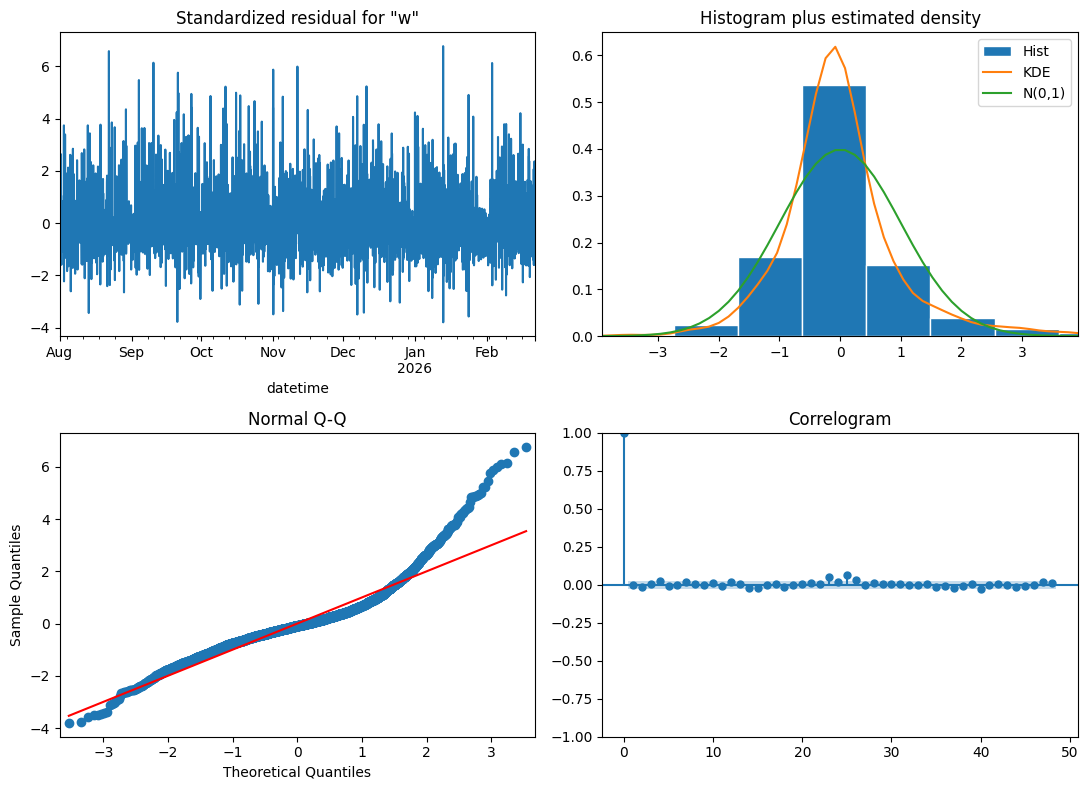

In [19]:
res_best.plot_diagnostics(figsize=(11, 8), lags=48)
plt.tight_layout()

**Interpretación del diagnóstico:**

- **Correlograma:** la gran mayoría de los lags del 1 al 48 caen dentro de la banda de confianza del 95%. Hay un par de lags (23 y 25) que asoman apenas por encima de la banda. Con 48 lags graficados es esperable por puro azar estadístico que algunos pocos caigan fuera del 95% aunque los residuos sean ruido blanco perfecto, así que estos excesos chicos justo en la zona estacional no justifican complicar el modelo. La lectura general es que el SARIMA absorbió la estructura temporal y la selección del orden $(p, q, P, Q)$ obtenida por AIC queda validada.
- **Residuos estandarizados en el tiempo:** oscilan alrededor de 0 sin tendencia ni cambio sistemático de varianza. Se ven algunos picos aislados de magnitud 4-7 (outliers) repartidos a lo largo de toda la serie, sin formar clusters que sugieran heterocedasticidad fuerte.
- **Histograma + KDE vs $\mathcal{N}(0,1)$:** la forma de la distribución empírica (KDE en naranja) no coincide con la normal de referencia (verde): hay más masa concentrada cerca de 0 (pico más alto) y más masa en las colas (al menos en la derecha), con menos masa en la zona intermedia. Sin embargo, las dos cosas se compensan y la varianza total se mantiene cerca de 1, pero la forma no es gaussiana.
- **Q-Q plot:** los puntos se alinean con la diagonal en el centro y en la cola izquierda (de $-3$ a $-1$ la desviación es mínima). El problema está en la cola derecha: a partir de $+1.5$ los _Sample Quantiles_ se elevan muy por encima de la diagonal (llegan a 6-7 cuando los _Theoretical Quantiles_ correspondientes son solo 3). Esto indica asimetría positiva: el modelo predice bien los vientos bajos y normales pero subestima los picos altos de `wind_avg` (rachas, eventos térmicos intensos). Tiene sentido físico porque la distribución del viento es asimétrica (no puede ser muy negativa, pero puede subir mucho) y los residuos heredan esa asimetría.

El modelo es válido para pronóstico puntual de `wind_avg`: la condición de ruido blanco (autocorrelación nula) se cumple, que es la hipótesis crítica del ajuste por máxima verosimilitud. La no-normalidad de los residuos (en el Q-Q plot) es esperable en series meteorológicas (eventos de viento extremos, rachas atípicas) y no invalida los coeficientes estimados; sin embargo, debe tenerse en cuenta al construir intervalos de confianza para las predicciones, ya que los basados en la hipótesis gaussiana van a subestimar la probabilidad de eventos extremos.

Con el modelo seleccionado y validado por residuos, queda definido el modelo estocástico de referencia. En la próxima sección lo evaluaremos por horizonte con la misma metodología de `TimeSeriesSplit` que usamos para el benchmark, y compararemos su desempeño contra la persistencia estacional.